# Sprint 6 - Repaso de Fundamentos de Python, Pandas y EDA (Ejercicios)

En estos ejercicios prácticos profundizaremos en uno de los conceptos más importantes de la estadística inferencial y del análisis de datos aplicado a la toma de decisiones: las **pruebas de hipótesis**. Como recordarás, el objetivo de estas herramientas consiste en determinar si la evidencia disponible en una muestra permite respaldar o rechazar una afirmación sobre una población. Gracias a este enfoque, es posible diferenciar entre cambios que se deben simplemente al azar y cambios que probablemente son consecuencia de una acción, intervención o fenómeno específico.

Para comprender mejor su aplicación práctica, trabajaremos con un tipo de estudio ampliamente utilizado en empresas que basan sus decisiones en información: las **Pruebas A/B**. Estas pruebas constituyen una metodología experimental efectiva cuyo propósito es evaluar si una modificación específica produce cambios medibles sobre un o varios indicadores de interés.

La lógica detrás de las pruebas A/B es relativamente sencilla. En primera instancia se divide a una población de entidades (i.e, clientes, productos, empleados, etc.) en dos grupos. Un grupo llamado de control o referencia, mantiene las condiciones habituales o existentes antes del experimento. Por su parte, un grupo de tratamiento o de investigación, recibe la modificación o intervención que se desea evaluar. Posteriormente, se comparan los resultados obtenidos por ambos grupos para determinar si las diferencias observadas son suficientemente significativas desde un punto de vista estadístico.

La simplicidad conceptual de las pruebas A/B no debe llevarnos a subestimar la importancia de un diseño experimental adecuado. De hecho, la calidad de las conclusiones obtenidas dependerá en gran medida de cómo se estructura y ejecuta el experimento. Un diseño deficiente puede conducir a resultados sesgados o interpretaciones incorrectas, independientemente de la sofisticación de las técnicas estadísticas utilizadas posteriormente.

En este sentido, es fundamental que exista una clara separación entre los grupos de control y tratamiento. Así también, resulta indispensable que la única diferencia relevante entre ambos grupos sea precisamente el factor que se desea evaluar. Si existen otros elementos que cambian simultáneamente durante el experimento, será difícil determinar cuál de ellos es realmente responsable de los resultados observados.

El tamaño de la muestra juega un papel determinante en la inferencia estadística, y por tanto lo hará de igual forma en una prueba A/B. Si el número de observaciones es demasiado pequeño, pueden existir diferencias reales entre los grupos que pasen desapercibidas debido a la variabilidad natural de los datos. Del mismo modo, un desequilibrio excesivo entre el tamaño de los grupos puede afectar la precisión de las estimaciones y la potencia estadística del análisis. 

A lo largo de este caso práctico aprenderemos entonces cómo diseñar experimentos sencillos bajo estos criterios, y practicar nuestra formulación de hipótesis estadísticas, para posteriormente aplicar pruebas inferenciales e interpretar correctamente sus resultados. De esta manera, incorporaremos una de las herramientas más utilizadas en la actualidad para la toma de decisiones basada en evidencia.

## Entendimiento el contexto

Una empresa que ofrece servicios de *call-center* enfrenta una situación delicada relacionada con la gestión de su talento humano. Durante una revisión periódica de indicadores operativos, la gerencia de operaciones detectó que uno de los agentes presenta registros que sugieren un posible incumplimiento recurrente de su jornada laboral. De acuerdo con los reportes preliminares, el tiempo efectivo de trabajo del colaborador sería inferior al esperado según las políticas internas de la organización. Como consecuencia, algunos directivos han planteado la posibilidad de proceder con su desvinculación, argumentando que este comportamiento afecta la productividad del equipo y genera una carga adicional sobre otros trabajadores.

Sin embargo, debido a los costos asociados a una terminación laboral de esta naturaleza, la dirección de la empresa ha decidido realizar una investigación más exhaustiva antes de adoptar cualquier medida. Además del impacto financiero que puede representar un despido, la organización es consciente de que una decisión incorrecta podría afectar el clima laboral y transmitir una señal negativa al resto de colaboradores. Por esta razón, se ha optado por brindar al trabajador la oportunidad de presentar sus argumentos y evidencias antes de emitir una resolución definitiva.

Durante la reunión de descargo, el operador cuestiona las conclusiones obtenidas por la gerencia y sostiene que los indicadores utilizados no reflejan adecuadamente su desempeño real. Según su versión, aunque podría registrar menos tiempo de conexión al sistema de gestión de clientes (CRM) que otros compañeros en determinados momentos, su nivel de concentración y productividad durante las horas efectivamente trabajadas es considerablemente superior. En particular, argumenta que mantiene una conexión más estable a dicho sistema, evitando interrupciones frecuentes y reduciendo tiempos improductivos que sí estarían presentes en otros miembros del equipo.

Adicionalmente, el trabajador afirma que su desempeño operativo supera al promedio de la organización. Como evidencia de ello, señala que su tasa de llamadas completadas o correctamente atendidas es superior a la observada en otros agentes, lo que le permitiría generar más valor para la empresa aun cuando sus patrones de conexión difieran de los estándares tradicionales. Desde su perspectiva, la evaluación debería centrarse en los resultados obtenidos y no únicamente en el tiempo registrado dentro de la plataforma de trabajo.

Ante la dificultad de determinar objetivamente cuál de las dos posiciones refleja con mayor precisión la realidad, el departamento de recursos humanos ha decidido recurrir al análisis de datos para respaldar su proceso de toma de decisiones. Para ello, te ha contratado con el objetivo de analizar la evidencia disponible y determinar si las diferencias observadas son estadísticamente significativas. Utilizando técnicas de inferencia estadística y pruebas A/B, deberás evaluar si el desempeño del colaborador realmente difiere del resto de operadores y si sus argumentos cuentan con suficiente respaldo cuantitativo. Los resultados de tu análisis servirán como base para que la empresa adopte una decisión justa, objetiva y sustentada en evidencia.

## Entendimiento de datos

### Ejercicio 1

Importa las librerías y módulos con los que trabajarás. Además de **Pandas** y **Matplotlib**, y dado que trabajarás con técnicas de inferencia estadística, te sugiero cargar también el módulo `stats` de **scipy**, y la función `proportions_ztest` de la librería **statsmodels**.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st
from statsmodels.stats.proportion import proportions_ztest

A continuación, carga los datos que te proporciona la empresa y con los cuales desarrollarás tus análisis. Estos datos se encuentran en el archivo [**employee_data.xlsx**](https://github.com/jsaraujo5081/material_curso_data_science/raw/refs/heads/main/datasets/employee_data.xlsx). Considera para esto que el archivo cuenta con dos pestañas (*Emp 1* y *Emp 2*), y que deberás cargar la información de cada una en dos datasets distintos.

In [2]:
# Cargar datos de Emp 1
df_emp1 = pd.read_excel(
    "https://github.com/jsaraujo5081/material_curso_data_science/raw/refs/heads/main/datasets/employee_data.xlsx", 
    sheet_name = "Emp 1"
)

# Mirar estructura de los datos
df_emp1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Day                    50 non-null     object 
 1   Hour                   50 non-null     int64  
 2   Minutes Active in CRM  50 non-null     int64  
 3   Completed Calls Rate   50 non-null     float64
dtypes: float64(1), int64(2), object(1)
memory usage: 1.7+ KB


In [3]:
# Cargar datos de Emp 2
df_emp2 = pd.read_excel(
    "https://github.com/jsaraujo5081/material_curso_data_science/raw/refs/heads/main/datasets/employee_data.xlsx", 
    sheet_name = "Emp 2"
)

# Mirar estructura de los datos
df_emp2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Day                    50 non-null     object 
 1   Hour                   50 non-null     int64  
 2   Minutes Active in CRM  50 non-null     int64  
 3   Completed Calls Rate   50 non-null     float64
dtypes: float64(1), int64(2), object(1)
memory usage: 1.7+ KB


### Ejercicio 2

La tabla en la pestaña *Emp 1* corresponde a información de la última semana del empleado investigado respecto a lo siguiente: 

* Day: Día de la semana en la que se tomaron los datos. 
* Hour: Hora del día en la que se tomaron los datos.
* Minutes Active in CRM: Minutos totales en dicha hora y día en los que el sistema reflejó actividad por parte del empleado.
* Completed Calls Rate: Porcentaje de llamadas debidamente completadas por parte del empleado respecto al total que atendió duante esa hora y día.

Explora este dataset generando una muestra del mismo, y mostrando un resumen estadístico de los indicadores existentes. 

In [4]:
# Generar muestra de datos
df_emp1.sample(10)

,Day,Hour,Minutes Active in CRM,Completed Calls Rate
24,Wednesday,12,26,0.556726
49,Friday,17,30,0.810000
26,Wednesday,14,28,0.698795
2,Monday,10,16,0.800000
27,Wednesday,15,32,0.810000
45,Friday,13,14,0.643498
18,Tuesday,16,31,0.810000
44,Friday,12,0,0.820000
21,Wednesday,9,24,0.642347
13,Tuesday,11,37,0.800000


In [5]:
# Visualizar distribucion de minutos y tasa de completitud
df_emp1[["Minutes Active in CRM", "Completed Calls Rate"]].describe().round(2)

,Minutes Active in CRM,Completed Calls Rate
count,50.00,50.00
mean,26.90,0.71
std,8.90,0.19
min,0.00,0.19
25%,22.25,0.65
50%,28.50,0.80
75%,33.00,0.83
max,40.00,0.90


Por su parte, la tabla en la pestaña *Emp 2* contiene la misma información promedio del equipo de operadores del call-center para la última semana.

Explora esta información generando los mismos resultados que antes.

In [6]:
# Generar muestra de datos
df_emp2.sample(10)

,Day,Hour,Minutes Active in CRM,Completed Calls Rate
24,Wednesday,12,44,0.769547
31,Thursday,9,30,0.629018
46,Friday,14,23,0.196935
49,Friday,17,20,0.638546
14,Tuesday,12,32,0.086624
0,Monday,8,36,0.720000
40,Friday,8,50,0.428802
41,Friday,9,38,0.710000
6,Monday,14,37,0.244169
2,Monday,10,39,0.305663


In [7]:
# Visualizar distribucion de minutos y tasa de completitud
df_emp2[["Minutes Active in CRM", "Completed Calls Rate"]].describe().round(2)

,Minutes Active in CRM,Completed Calls Rate
count,50.00,50.00
mean,36.52,0.52
std,11.36,0.24
min,10.00,0.02
25%,30.00,0.34
50%,37.00,0.47
75%,44.75,0.73
max,55.00,0.85


## Preparación de datos

### Ejercicio 1

A continuación podrás evidenciar el siguiente plan de acción para preparar los datos adecuadamente a fin de ejecutar los análisis posteriores.

**PLAN DE ACCIÓN PARA PREPARACIÓN DE DATOS**

| # | Acción |
| ---- | ---- |
| 1 | Incorporar en cada dataset una columna que identifique al empleado que corresponda. |
| 2 | Concatenar los datasets para tener una sola fuente de información con la que ejecutar los análisis posteriores. |
| 3 | Cambiar los nombres de la tabla para que se encuentre en formato snake_case. |
| 4 | Incorporar una columna con el dia de la semana en formato numerico para mayor facilidad de ordenamiento en el análisis. |

Ejecuta la primera de estas acciones, esto es, incorpora una nueva columna en cada dataset identificando al empleado que corresponde.

In [8]:
df_emp1["employee"] = "investigated"
df_emp2["employee"] = "reference"
print(df_emp1.info())
print()
print(df_emp2.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Day                    50 non-null     object 
 1   Hour                   50 non-null     int64  
 2   Minutes Active in CRM  50 non-null     int64  
 3   Completed Calls Rate   50 non-null     float64
 4   employee               50 non-null     object 
dtypes: float64(1), int64(2), object(2)
memory usage: 2.1+ KB
None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Day                    50 non-null     object 
 1   Hour                   50 non-null     int64  
 2   Minutes Active in CRM  50 non-null     int64  
 3   Completed Calls Rate   50 non-null     float64
 4   employee               50 non-null     object 


A continuación concatena los dos datasets.

In [9]:
df_consolidado = pd.concat(
    [df_emp1, df_emp2]
)
df_consolidado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, 0 to 49
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Day                    100 non-null    object 
 1   Hour                   100 non-null    int64  
 2   Minutes Active in CRM  100 non-null    int64  
 3   Completed Calls Rate   100 non-null    float64
 4   employee               100 non-null    object 
dtypes: float64(1), int64(2), object(2)
memory usage: 4.7+ KB


### Ejercicio 2

Cambia los nombres de las columas para que estén en formato snake_case.

In [10]:
df_consolidado.columns = [x.lower().replace(" ","_") for x in df_consolidado.columns]
df_consolidado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, 0 to 49
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   day                    100 non-null    object 
 1   hour                   100 non-null    int64  
 2   minutes_active_in_crm  100 non-null    int64  
 3   completed_calls_rate   100 non-null    float64
 4   employee               100 non-null    object 
dtypes: float64(1), int64(2), object(2)
memory usage: 4.7+ KB


Finalmente, incorpora una columna auxiliar que contenga los dias de la semana a modo de número. Es decir, los días Lunes deben motrar el valor de 1 en esta columna, los Martes 2, y así en adelante.

In [11]:
dic_days = {
    "Monday": 1,
    "Tuesday": 2,
    "Wednesday": 3,
    "Thursday": 4,
    "Friday": 5
}

df_consolidado["nday"] = df_consolidado["day"].map(dic_days)
df_consolidado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, 0 to 49
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   day                    100 non-null    object 
 1   hour                   100 non-null    int64  
 2   minutes_active_in_crm  100 non-null    int64  
 3   completed_calls_rate   100 non-null    float64
 4   employee               100 non-null    object 
 5   nday                   100 non-null    int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 5.5+ KB


## Análisis exploratorio de datos

### Ejercicio 1

Procedamos estudiando en mayor detalle el comportamiento de los indicadores de interés. Dado que por el contexto nos interesa estudiar la centralidad y la dispersión de los minutos activos de los empleados, muestra la media y la desviación estandar de la variable tanto para el empleado investigado como para el caso referencial.

In [12]:
(
    df_consolidado
    .groupby("employee")
    ["minutes_active_in_crm"]
    .describe()
    .transpose()
    .loc[["mean","std"]]
    .round(2)
)

employee,investigated,reference
mean,26.9,36.52
std,8.9,11.36


Para mirar en más detalle esta información, compara las distribuciones de minutos mediante gráficas de cajón con bigote. 

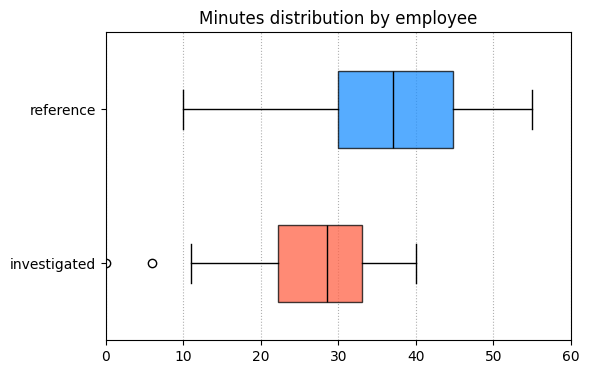

In [13]:
# Generar dataset agregado de minutos
mins_by_employee = df_consolidado.pivot_table(
    index = ["nday","day","hour"],
    columns = "employee",
    values = "minutes_active_in_crm",
    aggfunc = "sum"
).reset_index()

# Comparar distribuciones de minutos con grafica de cajon
fig = mins_by_employee[["investigated", "reference"]].plot(
    kind = "box",
    vert = False,
    widths = 0.5,
    figsize = [6,4],
    xlim = [0,60],
    title = "Minutes distribution by employee",
    color = "black",
    patch_artist = True,
    return_type="dict"
)
colors = ["tomato", "dodgerblue"]
for patch, color in zip(fig["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
plt.grid(axis = "x", linestyle = ":")
plt.show()

Complementa esta comparación con gráficas de densidad.

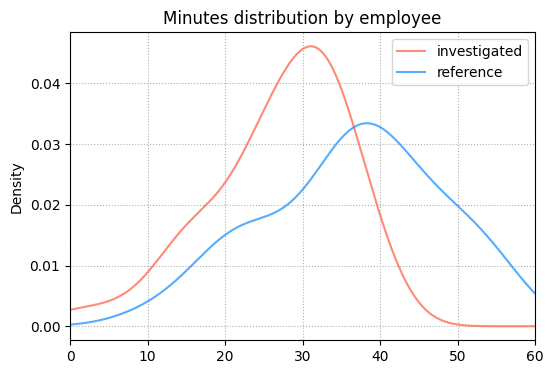

In [14]:
mins_by_employee[["investigated", "reference"]].plot(
    kind = "density",
    color = ["tomato", "dodgerblue"],
    alpha = 0.75,
    figsize = [6,4],
    xlim = [0,60],
    title = "Minutes distribution by employee"
)
plt.legend(title = "")
plt.grid(linestyle = ":")
plt.show()

En vista que esta información se encuentra distribuida a través del tiempo, igualmente has una comparación de los minutos de actividad por grupo de empleado mediante una evloución durante la semana de análisis.

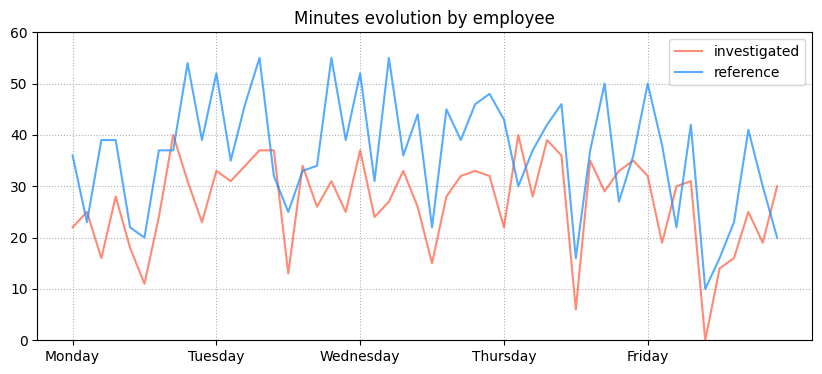

In [15]:
plt.figure(figsize = [10, 4])
plt.plot(
    mins_by_employee["investigated"],
    color = "tomato",
    alpha = 0.75
)
plt.plot(
    mins_by_employee["reference"],
    color = "dodgerblue",
    alpha = 0.75
)
plt.legend(["investigated", "reference"])
plt.title("Minutes evolution by employee")
plt.xticks(
    ticks = range(0,len(mins_by_employee),10),
    labels = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
)
plt.ylim([0,60])
plt.grid(linestyle = ":")
plt.show()

En base a estos resultados, existirían indicios que en efecto el empleado investigado tiene menor tiempo de trabajo que los demás, aunque su tiempo de trabajo sería más estable (menos volatil).

### Ejercicio 2

Procedamos ahora a estudiar el indicador de tasa de completitud de llamadas. Al igual que antes extrae el promedio y la desviación estandar de este indicador por grupo de empleado.

In [16]:
(
    df_consolidado
    .groupby("employee")
    ["completed_calls_rate"]
    .describe()
    .transpose()
    .loc[["mean","std"]]
    .round(2)
)

employee,investigated,reference
mean,0.71,0.52
std,0.19,0.24


Procede con una comparativa visual de la ditribución de estas variables a través de cajones con bigotes.

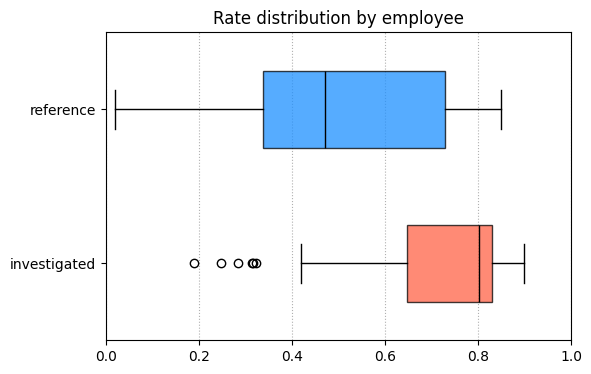

In [17]:
# Generar dataset agregado de tasa de llamadas completadas
rate_by_employee = df_consolidado.pivot_table(
    index = ["nday", "day", "hour"],
    columns = "employee",
    values = "completed_calls_rate",
    aggfunc = "mean"
).reset_index()

# Comparar distribuciones de minutos con grafica de cajon
fig = rate_by_employee[["investigated", "reference"]].plot(
    kind = "box",
    vert = False,
    widths = 0.5,
    figsize = [6,4],
    xlim = [0,1],
    title = "Rate distribution by employee",
    color = "black",
    patch_artist = True,
    return_type="dict"
)
colors = ["tomato", "dodgerblue"]
for patch, color in zip(fig["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
plt.grid(axis = "x", linestyle = ":")
plt.show()

Complementa tu análisis comparativo con unas gráficas de densidad.

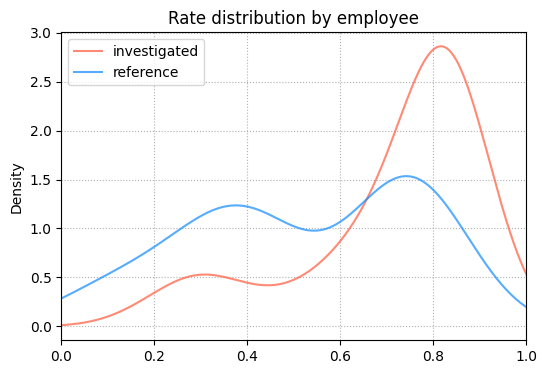

In [18]:
rate_by_employee[["investigated", "reference"]].plot(
    kind = "density",
    color = ["tomato", "dodgerblue"],
    alpha = 0.75,
    figsize = [6,4],
    xlim = [0,1],
    title = "Rate distribution by employee"
)
plt.legend(title = "")
plt.grid(linestyle = ":")
plt.show()

Mira finalmente la evolución durante la semana del indicador.

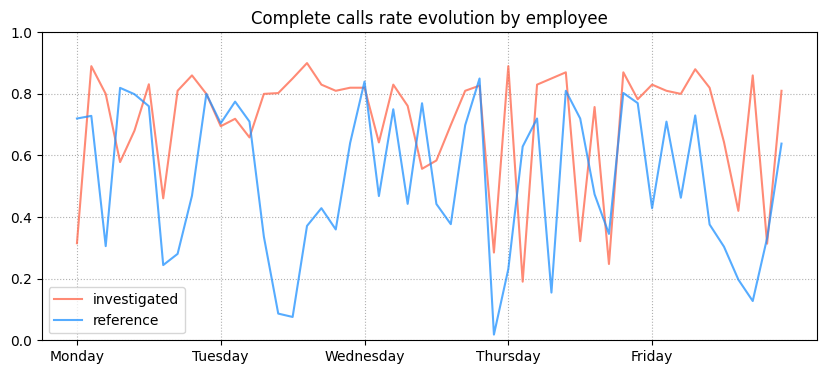

In [19]:
plt.figure(figsize = [10, 4])
plt.plot(
    rate_by_employee["investigated"],
    color = "tomato",
    alpha = 0.75
)
plt.plot(
    rate_by_employee["reference"],
    color = "dodgerblue",
    alpha = 0.75
)
plt.legend(["investigated", "reference"])
plt.title("Complete calls rate evolution by employee")
plt.xticks(
    ticks = range(0,len(rate_by_employee),10),
    labels = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
)
plt.ylim([0,1])
plt.grid(linestyle = ":")
plt.show()

Estos resultados evidenciarían que el operador investigado en efecto tiene mejor rendimiento en cuanto a completitud de llamadas. Sin embargo, al tener solamente información de la última semana necesitamos aplicar métodos de inferencia para poder generalizar estas conclusiones. 

## Prueba A/B 

### Ejercicio 1

Comencemos estudiando la variabilidad de los minutos activos en el CRM. Si recuerdas, el colaborador investigado afirmaba que su tiempo de trabajo, si bien podía ser menor al del resto de compañeros, era más estable y homogeneo. Para verificar si tiene razón, inicia planteando una hipótesis nula y una alternativa. 

| Hipótesis | Postulado |
| ---- | ---- |
| Nula | El empleado investigado tiene IGUAL variabilidad en sus minutos activo que el empleado de referencia. |
| Alternativa | El empleado investigado tiene MENOR variabilidad en sus minutos activo que el empleado de referencia. |

Extrae las correspondientes muestras de minutos activo para los dos grupos de empleados.

In [20]:
sample_inv = mins_by_employee["investigated"]
sample_ref = mins_by_employee["reference"]

Dado que del análisis exploratorio se desprende que existe cierta forma normal en la distribución de estas muestras, utiliza un **test de Bartlett** para extraer el valor p asociado. Considera que este estadístico debe ajustarse al tener un test de "una cola". 

In [21]:
# Extraer valor p de prueba de Bartlett
p_value = st.bartlett(sample_inv, sample_ref).pvalue

# Ajustar valor p para prueba de 1 cola
if sample_inv.std() < sample_ref.std():
    p_value_1t = p_value / 2
else:
    p_value_1t = 1 - p_value / 2
print(f"Valor p: {p_value_1t:.1%}")

Valor p: 3.4%


Aplica el criterio de decisión de inferencia estadística con un nivel de significancia del 5%.

In [22]:
if p_value_1t > 0.05:
    print("Empleado investigado tendría IGUAL volatilidad de minutos que la referencia.")
else:
    print("Empleado investigado tendría MENOR volatilidad de miutos que la referencia.") 

Empleado investigado tendría MENOR volatilidad de miutos que la referencia.


Mediante la lógica estadística de esta prueba A/B, se podría ratificar lo argumentado por el empleado respecto a que su tiempo de actividad es más estable.

### Ejercicio 2

Procedamos ahora a evaluar si este tiempo es menor en promedio al del resto de operadores de la empresa. Plantea las hipótesis nula y alternativa correspondientes.

| Hipótesis | Postulado |
| ---- | ---- |
| Nula | El empleado investigado tiene IGUAL promedio de minutos activo que el empleado de referencia. |
| Alternativa | El empleado investigado tiene MENOR promedio de minutos activo que el empleado de referencia. |

Mediante un **test t**, obtén el valor p asociado. Considera que del ejercicio anterior se ha verificado que la variabilidad entre los grupos no es igual.

In [23]:
p_value = st.ttest_ind(
    sample_inv, 
    sample_ref, 
    alternative = "less", 
    equal_var = "False"
).pvalue
print(f"Valor p: {p_value:.1%}")

Valor p: 0.0%


Aplica el criterio de decisión de inferencia estadística con un nivel de significancia del 5%.

In [24]:
if p_value > 0.05:
    print("Empleado investigado tendría IGUAL promedio de minutos que la referencia.")
else:
    print("Empleado investigado tendría MENOR promedio de minutos que la referencia.") 

Empleado investigado tendría MENOR promedio de minutos que la referencia.


Mediante la lógica estadística de esta prueba A/B, se podría ratificar lo argumentado por la gerencia respecto a que el tiempo de actividad del empleado es menor que el de otros colaboradores.

### Ejercicio 3

Queda finalmente verificar si el indicador de completitud de llamadas es mayor para el caso de la persona investigada. Plantea las hipótesis nula y alternativa.

| Hipótesis | Postulado |
| ---- | ---- |
| Nula | El empleado investigado tiene IGUAL tasa de llamadas completadas que el empleado de referencia. |
| Alternativa | El empleado investigado tiene MAYOR tasa de llamadas completadas que el empleado de referencia. |

Extrae las muestras de datos correspondientes para esta prueba. 

In [25]:
sample_inv = rate_by_employee["investigated"]
sample_ref = rate_by_employee["reference"]

Dado que el indicador corresponde a un porcentaje, conviene realizar un **test z de proporciones**. Entonces genera una lista que contenga dos valores:

* El primero corresponde a la estimación de llamadas completadas que tendrá el empleado investigado de un total de 100 ejecutadas.
* El segundo corresponde a la estimación de llamadas competadas que tendrá el resto de operadores de un total de 100 ejecutadas.

In [26]:
# Generar lista con exitos por tipo de empleado
mean_inv = sample_inv.mean()
mean_ref = sample_ref.mean()
success = [int(100 * mean_inv), int(100 * mean_ref)]

Utiliza esta lista para realizar la prueba y extraer el valor p asociado. Incorporar por tanto la lista como argumento de la función `proportions_ztest`.

In [27]:
# Obtener valor p
p_value = proportions_ztest(
    count = success,
    nobs = [100, 100],
    alternative = "larger"
)[1]
print(f"Valor p: {p_value:.1%}")

Valor p: 0.3%


Aplica el criterio de decisión de inferencia estadística con un nivel de significancia del 5%.

In [28]:
# Aplicar criterio de decision
if p_value > 0.05:
    print("Empleado investigado tendría IGUAL tasa de llamadas completadas que la referencia.")
else:
    print("Empleado investigado tendría MAYOR tasa de llamadas completadas que la referencia.") 

Empleado investigado tendría MAYOR tasa de llamadas completadas que la referencia.


Mediante la lógica estadística de esta prueba A/B, se podría ratificar lo argumentado por el empleado que su rendimiento en cuanto a tasa de llamadas completadas es mayor.

### Ejercicio 4

Genera una conclusión adecuada a brindar a la empresa y que le permita tomar una decisión justa y adecuada en esta caso.

| # | Conclusión |
| ---- | ---- |
| 1 | Si bien el empleado investigado trabaja menos tiempo que los demás miembros del equipo, durante este tiempo su trabajo es más estable y con mejores resultados en cuanto a llamadas completadas. Por lo expuesto, se recomienda no proceder con la solicitud de desvinculación dado que la persona se ha mostrado como alguien eficiente y beneficioso para la organización. | 